# AERPAW-SIONNA Validation
This notebook aims to validate the AERPAW-Sionna backend developed here https://github.com/AERPAW/AERPAW-DT-SIONNA-EXTENSION

### This notebook includes testing and model validation for:
* Coordinate Reference System Alignment
* SNR Alignment with CHEM and Ground Truth Testbed measurements
* Endpoint Validation
* Request and GPU Computational Latency vs. Accuracy

In [1]:
# Imports
import sys
import folium
import requests
import sionna.rt
import mitsuba as mi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum
from typing import Optional, Final, Tuple, Dict, List
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver
from pyproj import Transformer
from pyproj.enums import TransformDirection

In [2]:
"""
Defining the Coordinate Conversion System used to translate between a 
global environment (lat/lon/alt -> deg/deg/m) to a local environment (x/y/z -> ft/ft/ft)
"""

# Position of LW1 in lat/lon/alt - (deg/deg/m)
ORIGIN_LAT_LON: Final[Dict[str, float]] = {"lat": 35.72750947, "lon": -78.69595819, "alt": 82.973}
# XYZ Offset Based on Lake Wheeler Scene - (ft/ft/ft)
# SIONNA_OFFSET: Final[List[float]] = [-113, 16, 120]
SIONNA_OFFSET: Final[List[float]] = [2020.5, 1971.5, 312]


class CoordinateConverter:
    """WGS84 converter between geodetic (lat/lon/alt) and local ENU coordinates."""

    def __init__(self, reference_origin: Optional[Dict[str, float]] = None):
        if not reference_origin:
            reference_origin = ORIGIN_LAT_LON
        self.origin = reference_origin

        pipeline = (
            f"+proj=pipeline "
            f"+step +proj=unitconvert +xy_in=deg +z_in=m +xy_out=rad +z_out=m "
            f"+step +proj=cart +ellps=WGS84 "
            f"+step +proj=topocentric +ellps=WGS84 "                            
            f"+lon_0={self.origin['lon']} +lat_0={self.origin['lat']} +h_0={self.origin['alt']} "
            f"+step +proj=affine +s11=0 +s12=1 +s21=-1 +s22=0 "  # Rotate local coordinates by 180 degrees
            f"+step +proj=unitconvert +xy_in=m +z_in=m +xy_out=m +z_out=m"    
        )

        self.transformer = Transformer.from_pipeline(pipeline)


    def update_reference_origin(self, origin: Dict[str, float]) -> Dict[str, float]:
        self.origin = origin
        pipeline = (
            f"+proj=pipeline "
            f"+step +proj=unitconvert +xy_in=deg +z_in=m +xy_out=rad +z_out=m "
            f"+step +proj=cart +ellps=WGS84 "
            f"+step +proj=topocentric +ellps=WGS84 "                            
            f"+lon_0={self.origin['lon']} +lat_0={self.origin['lat']} +h_0={self.origin['alt']} "
            f"+step +proj=affine +s11=0 +s12=1 +s21=-1 +s22=0 "  # Rotate local coordinates by 180 degrees
            f"+step +proj=unitconvert +xy_in=m +z_in=m +xy_out=m +z_out=m"    
        )

        self.transformer = Transformer.from_pipeline(pipeline)
        return self.origin


    def get_origin(self) -> Dict[str, float]:
        return self.origin


    def lat_lon_alt_to_local(
        self, lat: float, lon: float, alt: float
    ) -> Tuple[float, float, float]:
        """Convert geodetic coordinate to local ENU tuple (x=east, y=north, z=up)."""
        east, north, up = self.transformer.transform(lon, lat, alt, direction=TransformDirection.FORWARD)
        return (east + SIONNA_OFFSET[0], north + SIONNA_OFFSET[1], up + SIONNA_OFFSET[2])


    def local_to_lat_lon_alt(
        self, x: float, y: float, z: float
    ) -> Tuple[float, float, float]:
        lon, lat, alt = self.transformer.transform(x - SIONNA_OFFSET[0],
                                                   y - SIONNA_OFFSET[1],
                                                   z - SIONNA_OFFSET[2], 
                                                   direction=TransformDirection.INVERSE)
        return (lat, lon, alt)

In [3]:
# Parsing SNR Data from Sandbox (CHEM) Experimental Data
def parseTimeToken(token):
    token = token.strip("]")
    comp = token.split(":")
    return int(comp[0]) * 3600 + int(comp[1]) * 60 + int(float(comp[2]))
    
num_aerpaw_bs = 4
snrs = []
for i in range(num_aerpaw_bs):
    snrs.append({})

with open("../data/aerpaw/vehicle_log.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(" ")
        for i in range(num_aerpaw_bs):
            if f"BS{i + 1}>SNR" in line:
                snrs[i][parseTimeToken(tokens[1])] = float(tokens[-1])

# Converting to pandas Dataframe
chem_df = pd.DataFrame()
chem_df.insert(0, "Time", list(snrs[0].keys()))
for i in range(num_aerpaw_bs):
    chem_df.insert(i + 1, f"LW{i + 1}", list(snrs[i].values()))

# Grabbing CHEM UAV position over time
# This should be the same as for the testbed, but just to confirm it's not offset
lat = {}
lon = {}
height = {}
with open("../data/aerpaw/vehicle_out.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(",")
        time = parseTimeToken(tokens[-3].split(" ")[1])
        lat[time] = float(tokens[2])
        lon[time] = float(tokens[1])
        height[time] = float(tokens[3])
        
chem_df.insert(1, "LAT", list(lat.values()))
chem_df.insert(2, "LON", list(lon.values()))
chem_df.insert(3, "ALT", list(height.values()))
print("Time goes from:", min(chem_df["Time"]), max(chem_df["Time"]))
print("Length", len(chem_df))
print(chem_df.head())

Time goes from: 57955 58390
Length 436
    Time        LAT        LON    ALT   LW1   LW2   LW3   LW4
0  57955  35.727123 -78.696275 -0.017 -99.0 -99.0 -99.0 -99.0
1  57956  35.727123 -78.696275 -0.017 -99.0 -99.0 -99.0 -99.0
2  57957  35.727123 -78.696275 -0.017 -99.0 -99.0 -99.0 -99.0
3  57958  35.727123 -78.696275 -0.017 -99.0 -99.0 -99.0 -99.0
4  57959  35.727123 -78.696275 -0.017 -99.0 -99.0 -99.0 -99.0


In [4]:
# Parsing SNR Data from Testbed Ground Truth Data
def parseTimeToken(token):
    token = token.strip("]")
    comp = token.split(":")
    return int(comp[0]) * 3600 + int(comp[1]) * 60 + int(float(comp[2]))
    
num_aerpaw_bs = 4
snrs = []
for i in range(num_aerpaw_bs):
    snrs.append({})

with open("../data/ground_truth_vehicle_log.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(" ")
        for i in range(num_aerpaw_bs):
            if f"BS{i + 1}>SNR" in line:
                snrs[i][parseTimeToken(tokens[1])] = float(tokens[-1])

# Converting to pandas Dataframe
test_df = pd.DataFrame()
test_df.insert(0, "Time", list(snrs[0].keys()))
for i in range(num_aerpaw_bs):
    test_df.insert(i + 1, f"LW{i + 1}", list(snrs[i].values()))

# Grabbing CHEM UAV position over time
# This should be the same as for the testbed, but just to confirm it's not offset
lat = {}
lon = {}
height = {}
with open("../data/ground_truth_uav_pos.txt", "r") as f:
    for line in f.readlines():
        tokens = line.split(",")
        time = parseTimeToken(tokens[-3].split(" ")[1])
        lat[time] = float(tokens[2])
        lon[time] = float(tokens[1])
        height[time] = float(tokens[3])
        
test_df.insert(1, "LAT", list(lat.values()))
test_df.insert(2, "LON", list(lon.values()))
test_df.insert(3, "ALT", list(height.values()))
print("Time goes from:", min(test_df["Time"]), max(test_df["Time"]))
print("Length", len(test_df))
print(test_df.head())

Time goes from: 55731 56217
Length 487
    Time       LAT        LON     ALT   LW1   LW2   LW3   LW4
0  55731  35.72749 -78.696305  16.103 -99.0 -99.0 -99.0 -99.0
1  55732  35.72749 -78.696305  16.115 -99.0 -99.0 -99.0 -99.0
2  55733  35.72749 -78.696305  16.107 -99.0 -99.0 -99.0 -99.0
3  55734  35.72749 -78.696305  16.108 -99.0 -99.0 -99.0 -99.0
4  55735  35.72749 -78.696305  16.103 -99.0 -99.0 -99.0 -99.0


## Alignment
Because the testbed and experimental data doesn't exactly line up, we need to confirm that
1) It is the same trajectory
2) Align those trajectories so that we are getting SNR information about the same positions over time

Result: After checking the trajectory visualization, I can confirm that they almost exactly the same trajectory, apart from some small differences at the start and end of the flight. It should be possible to overlay them or at least link the SNR values from the CHEM data to the closest point in the ground truth. 

In [5]:
# Visualizing the trajectories against satellite data to confirm equivalence
center_coords = [chem_df["LAT"].iloc[0], chem_df["LON"].iloc[0]]

# CHEM Trajectory
m = folium.Map(location=center_coords, zoom_start=12, tiles="Esri.WorldImagery")
for i in range(len(chem_df)):
    pos = [chem_df["LAT"].iloc[i], chem_df["LON"].iloc[i]]
    folium.CircleMarker(location=pos, 
                        radius=2,
                        popup=f"pos_{i}",
                        fill=True,
                        fill_color="green",
                        fill_opacity=1).add_to(m)   
m.save("lake_wheeler_trajectory_chem.html")
    
# Ground Truth Trajectory
m = folium.Map(location=center_coords, zoom_start=12, tiles="Esri.WorldImagery")
for i in range(len(test_df)):
    pos = [test_df["LAT"].iloc[i], test_df["LON"].iloc[i]]
    folium.CircleMarker(location=pos, 
                        radius=2,
                        popup=f"pos_{i}",
                        fill=True,
                        fill_color="green",
                        fill_opacity=1).add_to(m)

m.save("lake_wheeler_trajectory_test.html")

In [6]:
"""
Linking CHEM SNR to the ground truth:
For every position in the ground truth measurement, we want to use the CHEM
SNR values that are closest to that position. We'll consider anything closer than
1 meter in euclidean space to be close enough to be comprable.
"""

snrs = []
cc = CoordinateConverter()
THRESHOLD = 14  # 14 meters in euclidean space
for i in range(len(test_df)):
    best_index = 0
    closest_dist = np.inf
    for j in range(len(chem_df)):
        test_pos = [test_df["LAT"].iloc[i], test_df["LON"].iloc[i], test_df["ALT"].iloc[i]]
        chem_pos = [chem_df["LAT"].iloc[j], chem_df["LON"].iloc[j], chem_df["ALT"].iloc[j]]
        dist = np.linalg.norm(np.array(cc.lat_lon_alt_to_local(test_pos[0], test_pos[1], test_pos[2])) - 
                              np.array(cc.lat_lon_alt_to_local(chem_pos[0], chem_pos[1], chem_pos[2])))
        if dist < closest_dist:
            closest_dist = dist
            best_index = j
    if closest_dist < THRESHOLD:
        snrs.append([chem_df[f"LW{k}"].iloc[best_index] for k in range(1, 5)])
    else:
        snrs.append([-99 for i in range(1, 5)])
        
# Putting these columns into the ground truth dataframe
snrs = np.array(snrs)
for i in range(4):
    test_df.insert(i + 1, f"CHEM_SNR_LW{i + 1}", snrs[:, i])

print(test_df.head())
test_df.to_csv("aligned_vehicle_data.csv")  # Saving data for AERPAW-SIONNA prediction later

    Time  CHEM_SNR_LW1  CHEM_SNR_LW2  CHEM_SNR_LW3  CHEM_SNR_LW4       LAT  \
0  55731         -99.0         -99.0         -99.0         -99.0  35.72749   
1  55732         -99.0         -99.0         -99.0         -99.0  35.72749   
2  55733         -99.0         -99.0         -99.0         -99.0  35.72749   
3  55734         -99.0         -99.0         -99.0         -99.0  35.72749   
4  55735         -99.0         -99.0         -99.0         -99.0  35.72749   

         LON     ALT   LW1   LW2   LW3   LW4  
0 -78.696305  16.103 -99.0 -99.0 -99.0 -99.0  
1 -78.696305  16.115 -99.0 -99.0 -99.0 -99.0  
2 -78.696305  16.107 -99.0 -99.0 -99.0 -99.0  
3 -78.696305  16.108 -99.0 -99.0 -99.0 -99.0  
4 -78.696305  16.103 -99.0 -99.0 -99.0 -99.0  


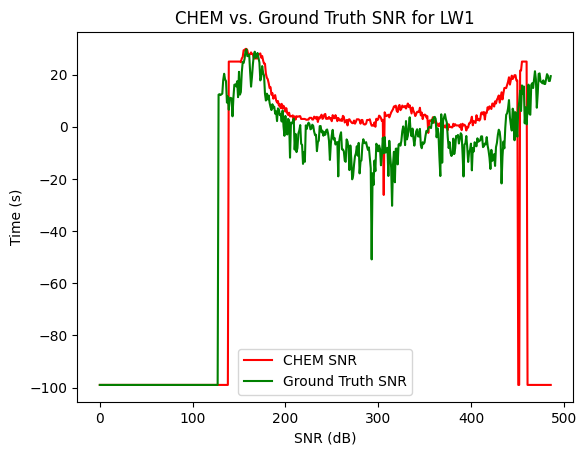

In [7]:
# Visualizing CHEM data vs. Ground Truth SNR Data
plt.plot(test_df["CHEM_SNR_LW1"], color="red", label="CHEM SNR")
plt.plot(test_df["LW1"], color="green", label="Ground Truth SNR")
plt.legend(loc="best")
plt.xlabel("SNR (dB)")
plt.ylabel("Time (s)")
plt.title("CHEM vs. Ground Truth SNR for LW1")
plt.show()

## Sionna Predicted Data
Next, we query the AERPAW-SIONNA backend with the positions to get the predicted SNR for those positions.
This SNR is then compared with the CHEM and ground truth data to hopefully show that the ray-tracing SNR
prediction is more accurate than the CHEM model.

In [8]:
# Defining some useful functions and variables for the next cell

# localhost
BASE_URL = "http://127.0.0.1:8000"
# The Boltzmann Constant in Joules/Kelvin
BOLTZMANN_CONSTANT = 1.380649e-23

def snr_from_cir_cw(gains, n_rx, n_tx, temperature):
    # Uses continuous wave merging (CW) instead of maximum ratio combining

    # 1. Extract gains and compute the squared magnitude (|h|^2)
    a_real = np.array(gains["real"], dtype=np.float64)
    a_imag = np.array(gains["imag"], dtype=np.float64)
    complex_gains = a_real + 1j * a_imag

    total_complex_gain = np.sum(complex_gains)

    # 2. Sum the path gains to get total wideband channel power gain
    # axis=2 is the num_paths dimension. Resulting shape: (n_rx, n_tx)
    channel_power_gain = np.abs(total_complex_gain) ** 2

    # 3. Compute total received Signal Power
    tx_power_w = 0.25  # Watts
    signal_power = channel_power_gain * tx_power_w

    # 4. Compute Thermal Noise Power
    bandwidth_hz = 150.0 * 1e6  # 30 MHz
    noise_power = BOLTZMANN_CONSTANT * temperature * bandwidth_hz

    # 5. Compute SNR in dB
    snr_db = 10 * np.log10(signal_power / noise_power)

    return snr_db

In [9]:
# This cell should take a little while to run

"""
Models how SNR changes wrt number of samples for 
a single transmitter-receiver system in this environment
"""

df = pd.read_csv("aligned_vehicle_data.csv")  # Grabbing previous dataframe

# Setting the transmitter to LW1
TRANSMITTER_HEIGHT = 10  # In meters from ground level
tx_pos = (35.72750947, -78.69595819, TRANSMITTER_HEIGHT)  # LW1

# Creating a new scene
response = requests.post(f"{BASE_URL}/scenes")
scene_id = response.json()["scene_id"]
print(f"Generated Scene Id: {scene_id}")

# Instantiating the transmitter
payload = {
    "name": f"lw1",
    "position": {
        "lat": tx_pos[0],
        "lon": tx_pos[1],
        "alt": tx_pos[2]
    },
    "velocity": {
        "x": 0,
        "y": 0,
        "z": 0
    },
    "signal_power": 2.0
}
response = requests.post(f"{BASE_URL}/scenes/{scene_id}/transmitters", json=payload)
assert response.status_code == 201

# Creating uav receiver
payload = {
    "name": f"uav",
    "position": {
        "lat": df["LAT"].iloc[0],
        "lon": df["LON"].iloc[0],
        "alt": df["ALT"].iloc[0]
    },
    "velocity": {
        "x": 0.0,
        "y": 0.0,
        "z": 0.0
    }
}
response = requests.post(f"{BASE_URL}/scenes/{scene_id}/receivers", json=payload)
assert response.status_code == 201

# Updating receiver position and querying SNR
snrs = []
for i in range(len(df)):
    # Updating the UAV's position
    payload = {
        "name": f"uav",
        "position": {
            "lat": df["LAT"].iloc[i],
            "lon": df["LON"].iloc[i],
            "alt": df["ALT"].iloc[i]
        },
        "velocity": {
            "x": 0.0,
            "y": 0.0,
            "z": 0.0
        }
    }
    response = requests.put(f"{BASE_URL}/scenes/{scene_id}/receivers/uav", json=payload)
    assert response.status_code == 200

    payload = {
        "max_depth": 3,
        "num_samples": 100000
    }
    response = requests.post(f"{BASE_URL}/scenes/{scene_id}/simulation/paths", json=payload)
    assert response.status_code == 200

    # Computing CIR
    response = requests.get(f"{BASE_URL}/scenes/{scene_id}/simulation/cir")
    assert response.status_code == 200

    # Computing SNR
    data = response.json()
    snr = snr_from_cir_cw(data["gains"], n_rx=1, n_tx=1, temperature=300)
    snrs.append(snr)

plt.plot(snrs, color="blue", label="Sionna")
plt.plot(df["CHEM_SNR_LW1"], color="red", label="CHEM")
plt.plot(df["LW1"], color="green", label="Ground Truth")
plt.xlabel("Timestamp (s)")
plt.ylabel("SNR (dB)")
plt.title("Sionna vs. CHEM vs. Ground Truth SNR over Time")
plt.legend(loc="best")
plt.show()

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /scenes (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7ad3abb568a0>: Failed to establish a new connection: [Errno 111] Connection refused'))

## Local Validation
* We want to validate the paths computed by the model to confirm that we are seeing correct behavior and trajectory throughout the experiment.
* Since there is no way to do this in the backend, we replicate the computation process in this notebook where visualization is possible.
* We visualize the computed paths and trajectory thoughout the sample experiment and compare this with the expected results from the SNR calculations. We can also compare the SNR values from this local test with the API data, although they should be identical.

In [11]:
# Initializing scene data
SCENE = "/home/everetttucker471/Documents/AERPAW-DT-SIONNA-EXTENSION/data/scenes/lake-wheeler-scene.xml"

# Default values for scene parameters
TEMPERATURE = 300.0  # Temperaure in Kelvin
BANDWIDTH = 30.0  # Bandwidth in MHz
TX_ARRAY = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.0, horizontal_spacing=0.0, pattern="iso", polarization="V")
RX_ARRAY = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.0, horizontal_spacing=0.0, pattern="iso", polarization="V")

# Scattering Coefficient Values
METAL_SC: Final[float] = 0.1
CONCRETE_SC: Final[float] = 0.3
GROUND_SC: Final[float] = 0.5

scene = load_scene(SCENE)

# Setting scattering coefficients
scene.objects.get("building-roofs").radio_material.scattering_coefficient = METAL_SC
scene.objects.get("building-roofs-shaped").radio_material.scattering_coefficient = METAL_SC
scene.objects.get("building-walls").radio_material.scattering_coefficient = CONCRETE_SC
scene.objects.get("terrain-mesh").radio_material.scattering_coefficient = GROUND_SC

scene.tx_array = TX_ARRAY
scene.rx_array = RX_ARRAY

scene.preview();

2026-04-23 20:14:33 WARN  [ply.h:299] "lake-wheeler-building-walls-output.ply": Mesh attribute "vertex_color" has integer fields: color attributes are expected to be in the [0, 1] range.
2026-04-23 20:14:33 WARN  [ply.h:299] "lake-wheeler-building-roofs-output.ply": Mesh attribute "vertex_color" has integer fields: color attributes are expected to be in the [0, 1] range.
2026-04-23 20:14:33 WARN  [PLYMesh] "lake-wheeler-building-roofs-shaped-output.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.
2026-04-23 20:14:33 WARN  [ply.h:299] "lake-wheeler-building-roofs-shaped-output.ply": Mesh attribute "vertex_color" has integer fields: color attributes are expected to be in the [0, 1] range.
2026-04-23 20:14:33 WARN  [PLYMesh] "terrain-mesh-small-output.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.
2026-04-23 2

In [ ]:
# Running the same experiment locally
# This cell should take a little while to run

import time

"""
Models how SNR changes wrt number of samples for 
a single transmitter-receiver system in this environment
"""

BOLTZMANN_CONSTANT = 1.380649e-23
def snr_from_cir_cw(complex_gains, n_rx, n_tx, temperature):
    # Uses continuous wave merging (CW) instead of maximum ratio combining
    total_complex_gain = np.sum(complex_gains)

    # Sum the path gains to get total wideband channel power gain
    # axis=2 is the num_paths dimension. Resulting shape: (n_rx, n_tx)
    channel_power_gain = np.abs(total_complex_gain) ** 2

    # 3. Compute total received Signal Power
    tx_power_w = 0.25  # Watts
    signal_power = channel_power_gain * tx_power_w

    # 4. Compute Thermal Noise Power
    bandwidth_hz = 150.0 * 1e6  # 30 MHz
    noise_power = BOLTZMANN_CONSTANT * temperature * bandwidth_hz

    # 5. Compute SNR in dB
    snr_db = 10 * np.log10(signal_power / noise_power)

    return snr_db

df = pd.read_csv("aligned_vehicle_data.csv")  # Grabbing previous dataframe

# Setting the transmitter to LW1
TRANSMITTER_HEIGHT = 10  # In meters from ground level
tx_pos = (35.72750947, -78.69595819, TRANSMITTER_HEIGHT)  # LW1

cc = CoordinateConverter()

# Instantiating the transmitter
scene.add(Transmitter(name="lw1", position=cc.lat_lon_alt_to_local(tx_pos[0], tx_pos[1], tx_pos[2]), velocity=(0, 0, 0)))

# Creating uav receiver
scene.add(Receiver(name="uav", position=cc.lat_lon_alt_to_local(df["LAT"].iloc[0], df["LON"].iloc[0], df["ALT"].iloc[0]), velocity=(0, 0, 0)))

# Updating receiver position and querying SNR

ps = PathSolver()

snrs = []
for i in range(len(df)):
    uav = scene._receivers["uav"]
    uav.position = cc.lat_lon_alt_to_local(df["LAT"].iloc[i], df["LON"].iloc[i], df["ALT"].iloc[i])

    # Computing Paths in the scene
    paths = ps(scene, 
               max_depth=3,
               max_num_paths_per_src=1000,
               samples_per_src=1000,
               synthetic_array=False,
               los=True,
               specular_reflection=True,
               diffuse_reflection=True,
               refraction=True,
               diffraction=True,
               edge_diffraction=True,
               diffraction_lit_region=True,
              )
    
    if i % 10 == 0:
        scene.preview(show_devices=True, paths=paths)
        break
    
    # Computing CIR
    a, tau = paths.cir(sampling_frequency=10,
                       num_time_steps=1,
                       out_type="numpy",
                      )

    # Computing SNR
    a = a.squeeze()
    print(a.shape)
    snr = snr_from_cir_cw(a, n_rx=1, n_tx=1, temperature=300)
    snrs.append(snr)

plt.plot(snrs, color="blue", label="Sionna")
plt.plot(df["CHEM_SNR_LW1"], color="red", label="CHEM")
plt.plot(df["LW1"], color="green", label="Ground Truth")
plt.xlabel("Timestamp (s)")
plt.ylabel("SNR (dB)")
plt.title("Sionna vs. CHEM vs. Ground Truth SNR over Time")
plt.legend(loc="best")
plt.show()

## Another Blender LiDAR Model
* This is Anil Gurses' model in Blender with buildings, LiDAR terrain, and procedurally generated terrain.
* Compared to my model, it doesn't have some of the rastering artifacts and I think the buildings are also more accurate
* I'm interested to see what this model predicts for SNR over the existing trajectory

In [ ]:
# Initializing scene data
SCENE = "/home/everetttucker471/Documents/AERPAW-DT-SIONNA-EXTENSION/data/anil/test.xml"

# Default values for scene parameters
TEMPERATURE = 300.0  # Temperaure in Kelvin
BANDWIDTH = 30.0  # Bandwidth in MHz
TX_ARRAY = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.0, horizontal_spacing=0.0, pattern="iso", polarization="V")
RX_ARRAY = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.0, horizontal_spacing=0.0, pattern="iso", polarization="V")

# Scattering Coefficient Values
METAL_SC: Final[float] = 0.1
CONCRETE_SC: Final[float] = 0.3
GROUND_SC: Final[float] = 0.5

scene = load_scene(SCENE)

# Setting scattering coefficients
print(scene.objects)

scene.tx_array = TX_ARRAY
scene.rx_array = RX_ARRAY

scene.preview();